## Description
1. [Imports](##-Imports) - Importing dependecies. 
2. [Text Classification](##-Text-Classification) - SMS spam dataset
3. 

### Imports

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer


## Text Classification

### Learning
- Tokenization
- Stop Words
- Stemming vs Lemmatization

In [2]:
stop_words = set(stopwords.words('english'))

In [6]:
words_to_compare = ["running", "runs", "ran", "studies", "argument", "better", "flies", "was"]

stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

comp = pd.DataFrame({
    'Original': words_to_compare,
    'Stemming': [stemmer.stem(w) for w in words_to_compare],
    'Lemmatized': [lemmatizer.lemmatize(w) for w in words_to_compare]
})
comp

,Original,Stemming,Lemmatized
0,running,run,running
1,runs,run,run
2,ran,ran,ran
3,studies,studi,study
4,argument,argument,argument
5,better,better,better
6,flies,fli,fly
7,was,wa,wa


In [25]:
sample = "I can't believe it's FREE!! Call now to claim your prize, urgent reply needed."

proper_tokens = word_tokenize(sample)


In [33]:

def preprocess_text(text, stop_words=stop_words):
    text = word_tokenize(text.lower())
    clean = [lemmatizer.lemmatize(w) for w in text if w.isalpha() and w not in stop_words]
    return " ".join(clean)

print(preprocess_text(sample))

ca believe free call claim prize urgent reply needed


In [30]:
print(preprocess_text(sample))

['ca', 'believe', 'free', 'call', 'claim', 'prize', 'urgent', 'reply', 'needed']


### SMS Spam Dataset

In [6]:
path = '../Data/sms.csv'
df = pd.read_csv(path).drop('Unnamed: 0', axis=1)
df['label'] = (df['label'] == 'spam').astype(int)
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(df['text'], y, stratify=y)
df.head()


,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [18]:

nb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words="english")),
    ('clsf', MultinomialNB())
])

scores = cross_val_score(nb_pipeline, X_train, y_train, cv=StratifiedKFold(5), scoring='f1')
print(f"CV F1 Score: {scores.mean():.4f}")

CV F1 Score: 0.8625


In [21]:
nb_pipeline.fit(X_train, y_train)

y_pred = nb_pipeline.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1207
           1       1.00      0.77      0.87       187

    accuracy                           0.97      1394
   macro avg       0.98      0.89      0.93      1394
weighted avg       0.97      0.97      0.97      1394



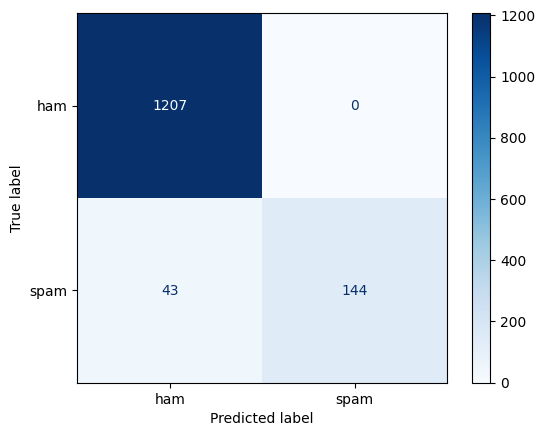

In [27]:
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(cm, display_labels=['ham', 'spam']).plot(cmap='Blues')

### Seeing what the model learnt

In [30]:
feature_names = nb_pipeline.named_steps['tfidf'].get_feature_names_out()
log_prob_ham, log_prob_spam = nb_pipeline.named_steps['clsf'].feature_log_prob_

spam_ratio = log_prob_spam - log_prob_ham
top_spam_idx = np.argsort(spam_ratio)[::-1][:20]

print("Top words most indicative of spam: ")
for i in top_spam_idx:
    print(f"   {feature_names[i]:<10s} logratio={spam_ratio[i]:.2f}")

Top words most indicative of spam: 
   claim      logratio=3.39
   prize      logratio=3.31
   www        logratio=3.17
   uk         logratio=2.96
   150p       logratio=2.91
   guaranteed logratio=2.89
   18         logratio=2.75
   1000       logratio=2.74
   tone       logratio=2.73
   100        logratio=2.62
   cs         logratio=2.60
   500        logratio=2.60
   awarded    logratio=2.54
   150ppm     logratio=2.51
   16         logratio=2.46
   000        logratio=2.40
   video      logratio=2.32
   valid      logratio=2.31
   tones      logratio=2.30
   entry      logratio=2.27


In [51]:
new_messages = [
    "URGENT! You have won a free cruise to the Bahamas! Call 1-800-555-0199 now to claim your prize!!!",
    "Hey, are you free this weekend? Want to grab coffee and catch up?",
]

for msg in new_messages:
    label = lambda p: 'SPAM' if p == 1 else 'ham'
    p = nb_pipeline.predict([msg])[0]
    pp = nb_pipeline.predict_proba([msg])[0, 1]
    print(f'"{msg[:60]}..."')
    print(f"   {label(p)} (P(spam) = {pp:.4f})\n")
    

"URGENT! You have won a free cruise to the Bahamas! Call 1-80..."
   SPAM (P(spam) = 0.9358)

"Hey, are you free this weekend? Want to grab coffee and catc..."
   ham (P(spam) = 0.0339)

